                             Parámetro  Valor (SI) Unidades
0             Barrera energética (E_b)  1.1295e-19        J
1       Frecuencia del pozo (\omega_0)  1.5172e+14      s⁻¹
2  Frecuencia de la barrera (\omega_b)  1.1452e+14      s⁻¹
3           Fricción del baño (\gamma)  7.3462e+14      s⁻¹


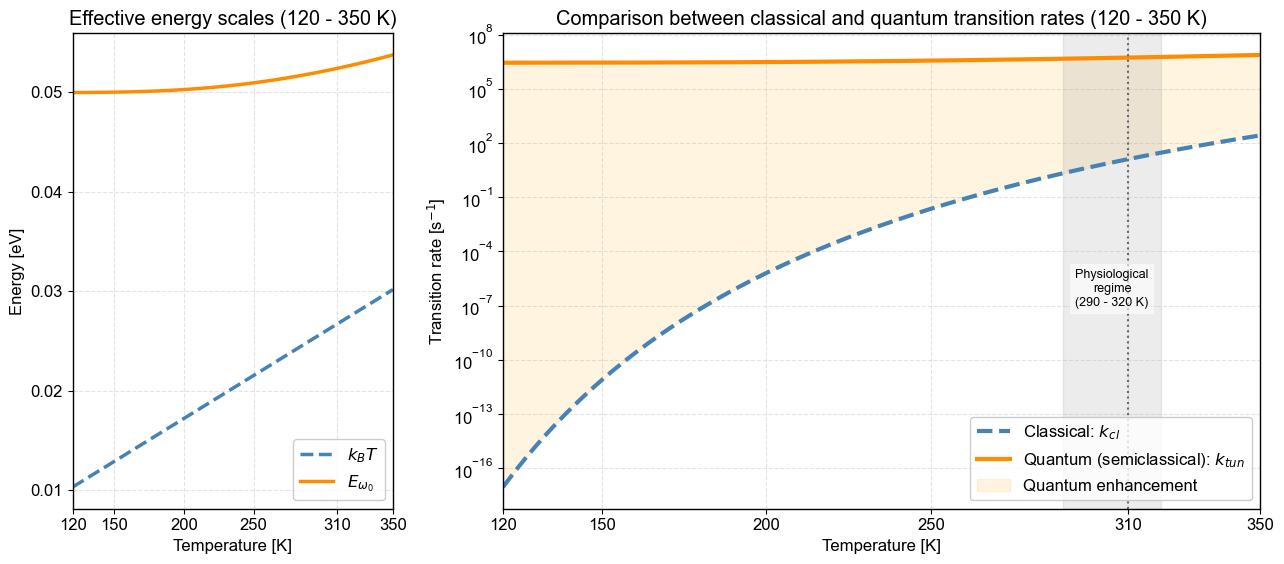

RESULTADOS A TEMPERATURA FISIOLÓGICA (310 K)

 Parámetros del sistema y prefactor:

Barrera (E_b)        = 1.1295e-19 J  (0.705 eV)
Frec. pozo (w_0)     = 1.517e+14 s^-1
Frec. barrera (w_b)  = 1.145e+14 s^-1
Fricción (gamma)     = 7.346e+14 s^-1
Prefactor (A)        = 3.764e+12 s^-1

 Comparativa energética a 310 K:

Energía térmica (k_B T) = 0.0267 eV
Energía efectiva (E_w0) = 0.0524 eV

 Tasas de transición a 310 K:

Tasa clásica (k_cl)     = 1.301e+01 s^-1
Tasa cuántica (k_q)     = 5.357e+06 s^-1

 Propiedades térmicas generales:

Temperatura crossover   ≈ 21.2 K


In [ ]:
# ============================================================
# TASAS DE TRANSICIÓN: KRAMERS VS SEMICLÁSICO
# Transferencia protónica en el ADN (par G-C)
# ============================================================



# IMPORTACIONES Y CONFIGURACIÓN GRÁFICA


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from scipy.constants import (
    k,          # Constante de Boltzmann [J/K]
    hbar,       # Constante reducida de Planck [J s]
    eV          # 1 eV en Joules
)

plt.style.use('default')

plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'normal'
plt.rcParams['font.weight'] = 'normal'



# CONVERSIÓN DE UNIDADES 


# Siendo 1 eV = 1.602176634e-19 J:
E_b_eV = 0.705
E_b = E_b_eV * eV

# 1 a.u. de frecuencia = 4.134137e16 s^-1

au_to_s_inv = 4.134137e16

omega_0 =  0.00367 * au_to_s_inv

omega_b = 0.00277 * au_to_s_inv

# En cuanto a la fricción del baño, el valor original (3900 cm^-1) proviene de la espectroscopíadel 
# agua (vibraciones O-H). Para integrarlo en las ecuaciones de Kramers y Caldeira-Leggett, debemos 
# convertir el número de onda (ν) a frecuencia angular (ω) en el SI (s^-1) y emplear c en [cm/s] 
# para cancelar los [cm^-1] del dato inicial, siendo este último:

c_cm_s = 2.997925e10

#Aplicamos:

gamma = 2 * np.pi * c_cm_s * 3900


# Creamos el diccionario con los resultados finales
data = {
    "Parámetro": [
        "Barrera energética (E_b)",
        "Frecuencia del pozo (\omega_0)",
        "Frecuencia de la barrera (\omega_b)",
        "Fricción del baño (\gamma)"
    ],
    "Valor (SI)": [E_b, omega_0, omega_b, gamma],
    "Unidades": ["J", "s⁻¹", "s⁻¹", "s⁻¹"]
}

# Generamos el DataFrame
df_parametros = pd.DataFrame(data)

# Formateamos para que se vea en notación científica con 4 decimales
pd.options.display.float_format = '{:.4e}'.format

print(df_parametros)



# Una vez tenemos los parámetros en SI, podemos proceder a preparar la base de trabajo y calcular las tasas de transición y la 
# temperatura de crossover utilizando las fórmulas presentadas en el TFGde Kramers y Caldeira-Leggett, respectivamente. 
# Para esto, es crucial definir un rango de temperaturas que sea relevante para el sistema biológico 
# que estamos estudiando.



# PRESENTACIÓN DE ECUACIONES Y CÁLCULOS




# ------------------------------------------------------------
# RANGO DE TEMPERATURA
# ------------------------------------------------------------
# El intervalo [120, 350] K se selecciona por su relevancia biofísica:
# 
# 1. Límite inferior (120 K): Umbral de transición donde el efecto túnel 
#    desde el estado fundamental (ZPE) comienza a dominar sobre la activación térmica.
# 2. Rango fisiológico (290-320 K): Región de interés biológico que incluye 
#    la temperatura del metabolismo humano (~310 K).
# 3. Límite superior (350 K): Punto de desnaturalización térmica; por encima 
#    de esta temperatura, la doble hélice pierde estabilidad estructural.

T = np.linspace(120, 350, 1500)

# ------------------------------------------------------------
# PREFACTOR DINÁMICO DE SMOLUCHOWSKI (Fricción Fuerte)
# Tenemos en cuenta la alta fricción del entorno.
#
# A = (ω0 * ωb) / (2π * γ)
#
# ------------------------------------------------------------

A = (omega_0 * omega_b) / (2 * np.pi * gamma)


# ------------------------------------------------------------
# TASA CLÁSICA. Ecuación (30).
#
# Límite de Smoluchowski (fricción fuerte). Representa la 
# probabilidad de salto por activación térmica pura.
#
# k_cl = (ω0 * ωb / 2πγ) * exp(-Eb / kBT)
#
# =------------------------------------------------------------

k_cl = A * np.exp(-E_b / (k * T))


# ------------------------------------------------------------
# ENERGÍA EFECTIVA CUÁNTICA. Ecuación (12).
#
# Eω0 = (ħω0 / 2) coth(ħω0 / 2kBT)
#
# =------------------------------------------------------------

def E_quantum(T):

    x = (hbar * omega_0) / (2 * k * T)

    coth_x = 1 / np.tanh(x)

    return (hbar * omega_0 / 2) * coth_x


# ------------------------------------------------------------
# TASA SEMICLÁSICA. Ecuación (33).
#
# Calculamos el prefactor de Smoluchowski y sustituimos la agitación 
# térmica por la energía efectiva del oscilador cuántico.
#
# k_q = (ω0 * ωb / 2πγ) * exp[-2Eb / (ħω0 coth(ħω0 / 2kBT))]
#
# ------------------------------------------------------------

k_q = A * np.exp(-E_b / E_quantum(T))


# ------------------------------------------------------------
# TEMPERATURA DE CROSSOVER (Fórmula Analítica Disipativa). Ecuación (7).
#
# T_c = (ħ*ω_b / 2π*k_B) * [ √(1 + γ² / 4ω_b²) - (γ / 2ω_b) ]
#
# ------------------------------------------------------------

# 1. Prefactor (T_c ideal en el límite sin fricción)
prefactor_Tc = (hbar * omega_b) / (2 * np.pi * k)

# 2. Factor de corrección por fricción 
termino_raiz = np.sqrt(1 + (gamma**2) / (4 * omega_b**2))
termino_resta = gamma / (2 * omega_b)
factor_correccion = termino_raiz - termino_resta

# 3. Cálculo final de la Temperatura de Crossover
T_cross = prefactor_Tc * factor_correccion




# CREACIÓN DE FIGURA


fig, (ax_energy, ax_rates) = plt.subplots(1, 2, figsize=(13, 5.8), gridspec_kw={'width_ratios': [1.1, 2.6]})


# ------------------------------------------------------------
# PANEL IZQUIERDO: ENERGÍAS EFECTIVAS
# ------------------------------------------------------------

ax_energy.grid(True, linestyle='--', alpha=0.35)


# ------------------------------------------------------------
# Energía térmica clásica: kBT
# (convertida a eV únicamente para representación)
# ------------------------------------------------------------

ax_energy.plot( T, (k * T) / eV, color='steelblue', linestyle='--', linewidth=2.5, label=r'$k_B T$')


# ------------------------------------------------------------
# Energía efectiva cuántica Eω0
# ------------------------------------------------------------

ax_energy.plot( T, E_quantum(T) / eV, color='darkorange', linewidth=2.5, label=r'$E_{\omega_0}$')



ax_energy.set_xlabel('Temperature [K]')
ax_energy.set_ylabel('Energy [eV]')
ax_energy.set_title('Effective energy scales (120 - 350 K)')

ax_energy.set_xlim(120, 350)
ax_energy.set_xticks([120, 150, 200, 250, 310, 350])

ax_energy.legend( loc='lower right', frameon=True, edgecolor='silver')




# PANEL DERECHO:
# TASAS DE TRANSICIÓN


ax_rates.grid(True, linestyle='--', alpha=0.35)


# ------------------------------------------------------------
# TASA CLÁSICA
# ------------------------------------------------------------

ax_rates.semilogy( T, k_cl, linewidth=3, color='steelblue', linestyle='--', label=r'Classical: $k_{cl}$')


# ------------------------------------------------------------
# TASA CUÁNTICA
# ------------------------------------------------------------

ax_rates.semilogy( T, k_q, linewidth=3, color='darkorange', linestyle='-', label=r'Quantum (semiclassical): $k_{tun}$')




# REGIONES DE DOMINANCIA


# ------------------------------------------------------------
# Región donde domina el efecto túnel (Tunneling Enhancement)
# Sombreamos el área donde la tasa cuántica supera a la clásica.
# Al no existir cruce en este rango, esta región cubre toda la gráfica.
# ------------------------------------------------------------

ax_rates.fill_between( T, k_cl, k_q, where=(k_q > k_cl), color='orange', alpha=0.12, interpolate=True, 
                      label='Quantum enhancement')




# TEMPERATURA DE CROSSOVER


if 120 <= T_cross <= 350:
    ax_rates.axvline( T_cross, color='red', linestyle=':', linewidth=1.7, label=r'Crossover temperature: $T_c$')

    ax_rates.text( T_cross + 4, np.sqrt(k_cl.max() * k_q.min()), rf'$T_c \approx {T_cross:.0f}\ \mathrm{{K}}$', fontsize=11) 


# ============================================================
# RÉGIMEN FISIOLÓGICO
# ============================================================

ax_rates.axvspan(290, 320, color='gray', alpha=0.15)


ax_rates.axvline(x=310, color='dimgray', linestyle=':', linewidth=1.5)

ax_rates.text( 305, 1e-7,'Physiological\nregime\n(290 - 320 K)', ha='center', fontsize=9, color='black', 
              bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))


# ============================================================
# AJUSTES FINALES
# ============================================================

ax_rates.set_xlabel('Temperature [K]')
ax_rates.set_ylabel(r'Transition rate [s$^{-1}$]')
ax_rates.set_title('Comparison between classical and quantum transition rates (120 - 350 K)')

ax_rates.set_xlim(120, 350)
ax_rates.set_xticks([120, 150, 200, 250, 310, 350])

ax_rates.legend( loc='lower right', frameon=True, edgecolor='silver')



# ============================================================
# ESTILO BORDES
# ============================================================

for ax in [ax_energy, ax_rates]:

    for spine in ax.spines.values():

        spine.set_color('black')
        spine.set_linewidth(1.0)



# ============================================================
# MOSTRAR FIGURA
# ============================================================

plt.tight_layout()
plt.show()


# ============================================================
# RESULTADOS NUMÉRICOS EN 310 K
# ============================================================

# Definimos la temperatura de evaluación
T_fisio = 310

# Calculamos las variables a esta temperatura: 
 
kT_310_eV = (k * T_fisio) / eV

E_w0_310_eV = E_quantum(T_fisio) / eV

k_cl_310 = A * np.exp(-E_b / (k * T_fisio))

k_q_310 = A * np.exp(-E_b / E_quantum(T_fisio))


print('================================================')
print(f'RESULTADOS A TEMPERATURA FISIOLÓGICA (310 K)')
print('================================================')

print('\n Parámetros del sistema y prefactor:')

print(f'\nBarrera (E_b)        = {E_b:.4e} J  ({E_b/eV:.3f} eV)')
print(f'Frec. pozo (w_0)     = {omega_0:.3e} s^-1')
print(f'Frec. barrera (w_b)  = {omega_b:.3e} s^-1')
print(f'Fricción (gamma)     = {gamma:.3e} s^-1')
print(f'Prefactor (A)        = {A:.3e} s^-1')

print('\n Comparativa energética a 310 K:')

print(f'\nEnergía térmica (k_B T) = {kT_310_eV:.4f} eV')
print(f'Energía efectiva (E_w0) = {E_w0_310_eV:.4f} eV')

print('\n Tasas de transición a 310 K:')

print(f'\nTasa clásica (k_cl)     = {k_cl_310:.3e} s^-1')
print(f'Tasa cuántica (k_q)     = {k_q_310:.3e} s^-1')

print('\n Propiedades térmicas generales:')

print(f'\nTemperatura crossover   ≈ {T_cross:.1f} K')


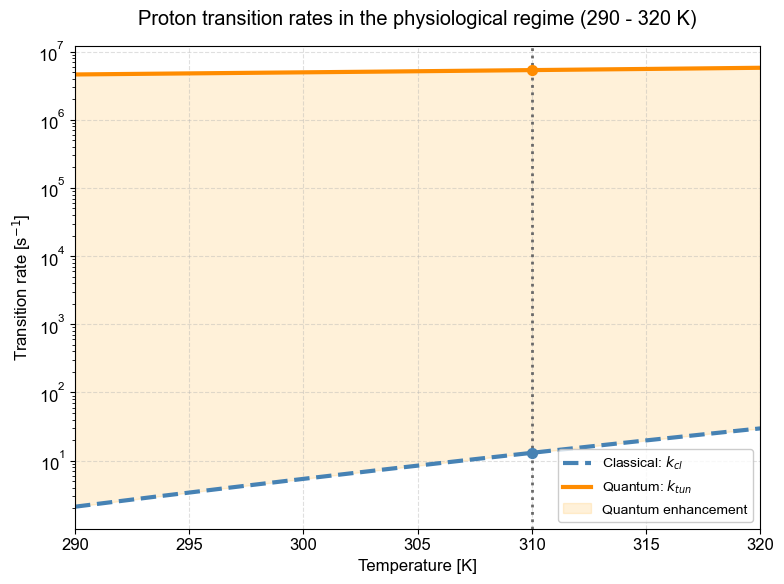

In [27]:
# ============================================================
# GRÁFICA RÉGIMEN FISIOLÓGICO 290 - 320 K
# ============================================================


T_fis = np.linspace(290, 320, 500)

# Recalculamos las tasas para este rango específico
k_cl_fis = A * np.exp(-E_b / (k * T_fis))
k_q_fis = A * np.exp(-E_b / E_quantum(T_fis))

plt.figure(figsize=(8, 6))
plt.grid(True, linestyle='--', alpha=0.4)

# Graficamos las tasas en escala logarítmica
plt.semilogy(T_fis, k_cl_fis, linewidth=3, color='steelblue', linestyle='--', label=r'Classical: $k_{cl}$')
plt.semilogy(T_fis, k_q_fis, linewidth=3, color='darkorange', linestyle='-', label=r'Quantum: $k_{tun}$')

# Sombreado del incremento cuántico 
plt.fill_between(T_fis, k_cl_fis, k_q_fis, color='orange', alpha=0.15, label='Quantum enhancement')

# Marcador para la temperatura de interés (310 K)
plt.axvline(x=310, color='dimgray', linestyle=':', linewidth=2)
plt.scatter([310], [k_q_310], color='darkorange', s=50, zorder=5) # Punto cuántico
plt.scatter([310], [k_cl_310], color='steelblue', s=50, zorder=5) # Punto clásico

#Formato
plt.xlabel('Temperature [K]', fontsize=12)
plt.ylabel(r'Transition rate [s$^{-1}$]', fontsize=12)
plt.title('Proton transition rates in the physiological regime (290 - 320 K)', pad=15)
plt.xlim(290, 320)
plt.xticks([290, 295, 300, 305, 310, 315, 320])

plt.legend(loc='lower right', frameon=True, edgecolor='silver', fontsize=10)

plt.tight_layout()
plt.show()

                             Parámetro  Valor (SI) Unidades
0             Barrera energética (E_b)  1.1295e-19        J
1       Frecuencia del pozo (\omega_0)  1.5172e+14      s⁻¹
2  Frecuencia de la barrera (\omega_b)  1.1452e+14      s⁻¹
3           Fricción del baño (\gamma)  7.3462e+14      s⁻¹


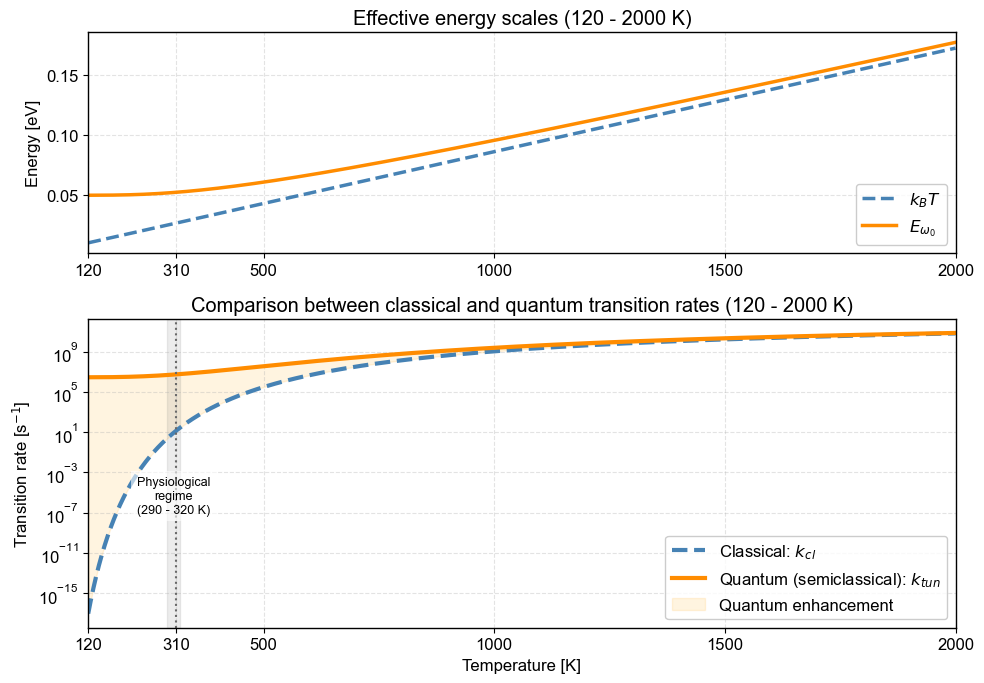

In [34]:
# ============================================================
# TASAS DE TRANSICIÓN: KRAMERS VS SEMICLÁSICO
# Transferencia protónica en el ADN (par G-C)
# ============================================================


# ============================================================
# IMPORTACIONES Y CONFIGURACIÓN GRÁFICA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from scipy.constants import (
    k,          # Constante de Boltzmann [J/K]
    hbar,       # Constante reducida de Planck [J s]
    eV          # 1 eV en Joules
)

plt.style.use('default')

plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'normal'
plt.rcParams['font.weight'] = 'normal'


# ============================================================
# CONVERSIÓN DE UNIDADES 
# ============================================================

# Siendo 1 eV = 1.602176634e-19 J:
E_b_eV = 0.705
E_b = E_b_eV * eV

# 1 a.u. de frecuencia = 4.134137e16 s^-1

au_to_s_inv = 4.134137e16

omega_0 =  0.00367 * au_to_s_inv

omega_b = 0.00277 * au_to_s_inv

# En cuanto a la fricción del baño, el valor original (3900 cm^-1) proviene de la espectroscopíadel 
# agua (vibraciones O-H). Para integrarlo en las ecuaciones de Kramers y Caldeira-Leggett, debemos 
# convertir el número de onda (ν) a frecuencia angular (ω) en el SI (s^-1) y emplear c en [cm/s] 
# para cancelar los [cm^-1] del dato inicial, siendo este último:

c_cm_s = 2.997925e10

#Aplicamos:

gamma = 2 * np.pi * c_cm_s * 3900


# Creamos el diccionario con los resultados finales
data = {
    "Parámetro": [
        "Barrera energética (E_b)",
        "Frecuencia del pozo (\omega_0)",
        "Frecuencia de la barrera (\omega_b)",
        "Fricción del baño (\gamma)"
    ],
    "Valor (SI)": [E_b, omega_0, omega_b, gamma],
    "Unidades": ["J", "s⁻¹", "s⁻¹", "s⁻¹"]
}

# Generamos el DataFrame
df_parametros = pd.DataFrame(data)

# Formateamos para que se vea en notación científica con 4 decimales
pd.options.display.float_format = '{:.4e}'.format

print(df_parametros)



# Una vez tenemos los parámetros en SI, podemos proceder a preparar la base de trabajo y calcular las tasas de transición y la 
# temperatura de crossover utilizando las fórmulas presentadas en el TFGde Kramers y Caldeira-Leggett, respectivamente. 
# Para esto, es crucial definir un rango de temperaturas que sea relevante para el sistema biológico 
# que estamos estudiando.


# ============================================================
# PRESENTACIÓN DE ECUACIONES Y CÁLCULOS
# ============================================================



# ------------------------------------------------------------
# RANGO DE TEMPERATURA
# ------------------------------------------------------------
# El intervalo [120, 350] K se selecciona por su relevancia biofísica:
# 
# 1. Límite inferior (120 K): Umbral de transición donde el efecto túnel 
#    desde el estado fundamental (ZPE) comienza a dominar sobre la activación térmica.
# 2. Rango fisiológico (290-320 K): Región de interés biológico que incluye 
#    la temperatura del metabolismo humano (~310 K).
# 3. Límite superior (350 K): Punto de desnaturalización térmica; por encima 
#    de esta temperatura, la doble hélice pierde estabilidad estructural.

T = np.linspace(120, 2000, 2500)

# ------------------------------------------------------------
# PREFACTOR DINÁMICO DE SMOLUCHOWSKI (Fricción Fuerte)
# Tenemos en cuenta la alta fricción del entorno.
#
# A = (ω0 * ωb) / (2π * γ)
#
# ------------------------------------------------------------

A = (omega_0 * omega_b) / (2 * np.pi * gamma)


# ------------------------------------------------------------
# TASA CLÁSICA. Ecuación (30).
#
# Límite de Smoluchowski (fricción fuerte). Representa la 
# probabilidad de salto por activación térmica pura.
#
# k_cl = (ω0 * ωb / 2πγ) * exp(-Eb / kBT)
#
# =------------------------------------------------------------

k_cl = A * np.exp(-E_b / (k * T))


# ------------------------------------------------------------
# ENERGÍA EFECTIVA CUÁNTICA. Ecuación (12).
#
# Eω0 = (ħω0 / 2) coth(ħω0 / 2kBT)
#
# =------------------------------------------------------------

def E_quantum(T):

    x = (hbar * omega_0) / (2 * k * T)

    coth_x = 1 / np.tanh(x)

    return (hbar * omega_0 / 2) * coth_x


# ------------------------------------------------------------
# TASA SEMICLÁSICA. Ecuación (33).
#
# Calculamos el prefactor de Smoluchowski y sustituimos la agitación 
# térmica por la energía efectiva del oscilador cuántico.
#
# k_q = (ω0 * ωb / 2πγ) * exp[-2Eb / (ħω0 coth(ħω0 / 2kBT))]
#
# ------------------------------------------------------------

k_q = A * np.exp(-E_b / E_quantum(T))


# ------------------------------------------------------------
# TEMPERATURA DE CROSSOVER (Fórmula Analítica Disipativa). Ecuación (7).
#
# T_c = (ħ*ω_b / 2π*k_B) * [ √(1 + γ² / 4ω_b²) - (γ / 2ω_b) ]
#
# ------------------------------------------------------------

# 1. Prefactor (T_c ideal en el límite sin fricción)
prefactor_Tc = (hbar * omega_b) / (2 * np.pi * k)

# 2. Factor de corrección por fricción 
termino_raiz = np.sqrt(1 + (gamma**2) / (4 * omega_b**2))
termino_resta = gamma / (2 * omega_b)
factor_correccion = termino_raiz - termino_resta

# 3. Cálculo final de la Temperatura de Crossover
T_cross = prefactor_Tc * factor_correccion



# ============================================================
# CREACIÓN DE FIGURA
# ============================================================

fig, (ax_energy, ax_rates) = plt.subplots(
    2, 1,
    figsize=(10, 10),
    gridspec_kw={'height_ratios': [1, 1.4]}
)

# ------------------------------------------------------------
# PANEL IZQUIERDO: ENERGÍAS EFECTIVAS
# ------------------------------------------------------------

ax_energy.grid(True, linestyle='--', alpha=0.35)


# ------------------------------------------------------------
# Energía térmica clásica: kBT
# (convertida a eV únicamente para representación)
# ------------------------------------------------------------

ax_energy.plot( T, (k * T) / eV, color='steelblue', linestyle='--', linewidth=2.5, label=r'$k_B T$')


# ------------------------------------------------------------
# Energía efectiva cuántica Eω0
# ------------------------------------------------------------

ax_energy.plot( T, E_quantum(T) / eV, color='darkorange', linewidth=2.5, label=r'$E_{\omega_0}$')



ax_energy.set_ylabel('Energy [eV]')
ax_energy.set_title('Effective energy scales (120 - 2000 K)')

ax_energy.set_xlim(120, 2000)
ax_energy.set_xticks([120, 310, 500, 1000, 1500, 2000])

ax_energy.legend( loc='lower right', frameon=True, edgecolor='silver')



# ============================================================
# PANEL DERECHO:
# TASAS DE TRANSICIÓN
# ============================================================

ax_rates.grid(True, linestyle='--', alpha=0.35)


# ------------------------------------------------------------
# TASA CLÁSICA
# ------------------------------------------------------------

ax_rates.semilogy( T, k_cl, linewidth=3, color='steelblue', linestyle='--', label=r'Classical: $k_{cl}$')


# ------------------------------------------------------------
# TASA CUÁNTICA
# ------------------------------------------------------------

ax_rates.semilogy( T, k_q, linewidth=3, color='darkorange', linestyle='-', label=r'Quantum (semiclassical): $k_{tun}$')



# ============================================================
# REGIONES DE DOMINANCIA
# ============================================================

# ------------------------------------------------------------
# Región donde domina el efecto túnel (Tunneling Enhancement)
# Sombreamos el área donde la tasa cuántica supera a la clásica.
# Al no existir cruce en este rango, esta región cubre toda la gráfica.
# ------------------------------------------------------------

ax_rates.fill_between( T, k_cl, k_q, where=(k_q > k_cl), color='orange', alpha=0.12, interpolate=True, 
                      label='Quantum enhancement')



# ============================================================
# TEMPERATURA DE CROSSOVER
# ============================================================

if 120 <= T_cross <= 1500:
    ax_rates.axvline( T_cross, color='red', linestyle=':', linewidth=1.7, label=r'Crossover temperature: $T_c$')

    ax_rates.text( T_cross + 4, np.sqrt(k_cl.max() * k_q.min()), rf'$T_c \approx {T_cross:.0f}\ \mathrm{{K}}$', fontsize=11) 


# ============================================================
# RÉGIMEN FISIOLÓGICO
# ============================================================

ax_rates.axvspan(290, 320, color='gray', alpha=0.15)


ax_rates.axvline(x=310, color='dimgray', linestyle=':', linewidth=1.5)

ax_rates.text( 305, 1e-7,'Physiological\nregime\n(290 - 320 K)', ha='center', fontsize=9, color='black', 
              bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))


# ============================================================
# AJUSTES FINALES
# ============================================================

ax_rates.set_xlabel('Temperature [K]')
ax_rates.set_ylabel(r'Transition rate [s$^{-1}$]')
ax_rates.set_title('Comparison between classical and quantum transition rates (120 - 2000 K)')

ax_rates.set_xlim(120, 2000)
ax_rates.set_xticks([120, 310, 500, 1000, 1500, 2000])

ax_rates.legend( loc='lower right', frameon=True, edgecolor='silver')



# ============================================================
# ESTILO BORDES
# ============================================================

for ax in [ax_energy, ax_rates]:

    for spine in ax.spines.values():

        spine.set_color('black')
        spine.set_linewidth(1.0)



## ============================================================
# CONFIGURACIÓN FINAL DE FIGURA (SUBPLOTS VERTICALES)
# ============================================================

fig.set_size_inches(10, 7)

ax_rates.set_xlim(120, 2000)

fig.tight_layout()



# ============================================================
# MOSTRAR FIGURAS
# ============================================================

plt.show()

